# Notebook 02 — Preprocesamiento de Datos
**NHANES 2013-2014 · Ciclo H · Autor: Nicholas**

**Objetivo:** Limpiar, imputar y transformar la tabla maestra para dejarla lista
para el modelado. Se produce `nhanes_2013_procesado.parquet` en `data/02_intermediate/`.

**Pasos:**
1. Carga y corrección de valores SAS missing (centinela `5.4e-79`)
2. Selección de variables útiles (de ~288 → subconjunto relevante)
3. Filtrado: solo adultos ≥18 años, eliminación de registros sin edad
4. Imputación: `KNNImputer` (numéricas) + `SimpleImputer` moda (categóricas)
5. Codificación One-Hot Encoding (`drop_first=True`)
6. Escalado `StandardScaler` (solo numéricas; no se escalan targets ni dummies)
7. Creación de variable objetivo `IS_LONGEVO` (1 si `RIDAGEYR ≥ 70`)
8. Exportación + metadatos JSON

---

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, json

from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams.update({'figure.figsize': (14, 6),
                     'axes.titleweight': 'bold', 'axes.titlesize': 14})

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Carga de datos crudos

In [2]:
DATA_PATH = '../data/01_raw/nhanes_2013_maestra.csv'

df = pd.read_csv(DATA_PATH)
print(f"Datos crudos cargados: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head(3)

Datos crudos cargados: 14,276 filas × 298 columnas


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,INDHHINC,INDFMINC,DMDHRBRN,BMXCALF,BMICALF,BMXTHICR,BMITHICR,BPXDB,SMD070,SMD075
0,73557.0,8.0,2.0,1.0,69.0,NaN,4.0,4.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,73558.0,8.0,2.0,1.0,54.0,NaN,3.0,3.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,73559.0,8.0,2.0,1.0,72.0,NaN,3.0,3.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Corrección de valores SAS missing

Los archivos `.xpt` de NHANES codifican ciertos faltantes especiales como `5.4e-79`.
Deben convertirse a `NaN` antes de cualquier cálculo.

In [3]:
SAS_SENTINEL = 1e-70   # cualquier positivo menor a esto es un missing SAS

n_sas_total = 0
cols_afectadas = []
for col in df.select_dtypes(include=[np.number]).columns:
    mask = (df[col] > 0) & (df[col] < SAS_SENTINEL)
    n = mask.sum()
    if n > 0:
        n_sas_total += n
        cols_afectadas.append((col, n))
        df.loc[mask, col] = np.nan

print(f"Valores SAS missing reemplazados por NaN: {n_sas_total:,}")
print(f"Columnas afectadas: {len(cols_afectadas)}")
for col, n in sorted(cols_afectadas, key=lambda x: -x[1])[:10]:
    print(f"  {col}: {n:,}")

Valores SAS missing reemplazados por NaN: 0
Columnas afectadas: 0


## 4. Selección de variables relevantes

De las ~288 columnas disponibles, seleccionamos las más relevantes para predecir
**Edad Biológica** y **Longevidad**:

| Grupo | Variables | Fuente |
|---|---|---|
| Demográficas | edad, género, etnia, educación, estado civil, ingresos | DEMO |
| Antropométricas | peso, talla, IMC, cintura, brazo, pierna | BMX |
| Presión arterial | sistólica, diastólica (3 lecturas), pulso | BPX |
| Laboratorio | colesterol total, glucosa | TCHOL / GLU |

In [4]:
cols_id   = ['SEQN']
cols_demo = ['RIDAGEYR', 'RIAGENDR', 'RIDRETH3', 'DMDEDUC2', 'DMDMARTL',
             'DMDHHSIZ', 'DMDFMSIZ', 'INDFMPIR']
cols_bmx  = ['BMXWT', 'BMXHT', 'BMXBMI', 'BMXWAIST', 'BMXLEG', 'BMXARML', 'BMXARMC']
cols_bp   = ['BPXSY1', 'BPXDI1', 'BPXSY2', 'BPXDI2', 'BPXSY3', 'BPXDI3', 'BPXPLS']
cols_lab  = ['LBXTC', 'LBXGLU']

cols_deseadas  = cols_id + cols_demo + cols_bmx + cols_bp + cols_lab
cols_seleccion = [c for c in cols_deseadas if c in df.columns]
cols_faltantes = [c for c in cols_deseadas if c not in df.columns]

if cols_faltantes:
    print(f"Columnas solicitadas pero no encontradas: {cols_faltantes}")

df = df[cols_seleccion + ['CICLO_ORIGEN']].copy()
print(f"Variables seleccionadas: {len(cols_seleccion)} de {len(cols_deseadas)}")
df.head(3)

Variables seleccionadas: 25 de 25


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,DMDMARTL,DMDHHSIZ,DMDFMSIZ,INDFMPIR,BMXWT,...,BPXSY1,BPXDI1,BPXSY2,BPXDI2,BPXSY3,BPXDI3,BPXPLS,LBXTC,LBXGLU,CICLO_ORIGEN
0,73557.0,69.0,1.0,4.0,3.0,4.0,3.0,3.0,0.84,78.3,...,122.0,72.0,114.0,76.0,102.0,74.0,86.0,167.0,NaN,2013-2014
1,73558.0,54.0,1.0,3.0,3.0,1.0,4.0,4.0,1.78,89.5,...,156.0,62.0,160.0,80.0,156.0,42.0,74.0,170.0,NaN,2013-2014
2,73559.0,72.0,1.0,3.0,4.0,1.0,2.0,2.0,4.51,88.9,...,140.0,90.0,140.0,76.0,146.0,80.0,68.0,126.0,193.0,2013-2014


## 5. Limpieza — filtrado de registros

In [5]:
antes = len(df)
df = df.dropna(subset=['RIDAGEYR'])
print(f"Eliminados {antes - len(df):,} registros sin edad.")

antes = len(df)
df = df[df['RIDAGEYR'] >= 18].copy()
print(f"Filtrado a adultos ≥18: {antes - len(df):,} menores eliminados.")
print(f"Dataset actual: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Eliminados 0 registros sin edad.
Filtrado a adultos ≥18: 4,062 menores eliminados.
Dataset actual: 10,214 filas × 26 columnas


## 6. Creación de la variable objetivo `IS_LONGEVO`

In [6]:
df['IS_LONGEVO'] = (df['RIDAGEYR'] >= 70).astype(int)

conteo = df['IS_LONGEVO'].value_counts()
print("Distribución de IS_LONGEVO (solo adultos):")
print(f"  No Longevo (0): {conteo.get(0,0):>6,}  {conteo.get(0,0)/len(df)*100:.1f}%")
print(f"  Longevo    (1): {conteo.get(1,0):>6,}  {conteo.get(1,0)/len(df)*100:.1f}%")

Distribución de IS_LONGEVO (solo adultos):
  No Longevo (0):  5,212  51.0%
  Longevo    (1):  5,002  49.0%


## 7. Separación en numéricas y categóricas

In [7]:
col_id          = 'SEQN'
col_target_bin  = 'IS_LONGEVO'
col_target_cont = 'RIDAGEYR'

cols_categoricas = [c for c in ['RIAGENDR', 'RIDRETH3', 'DMDEDUC2', 'DMDMARTL']
                    if c in df.columns]
cols_numericas   = [c for c in [
    'DMDHHSIZ', 'DMDFMSIZ', 'INDFMPIR',
    'BMXWT', 'BMXHT', 'BMXBMI', 'BMXWAIST', 'BMXLEG', 'BMXARML', 'BMXARMC',
    'BPXSY1', 'BPXDI1', 'BPXSY2', 'BPXDI2', 'BPXSY3', 'BPXDI3', 'BPXPLS',
    'LBXTC', 'LBXGLU',
] if c in df.columns]

print(f"Variables categóricas ({len(cols_categoricas)}): {cols_categoricas}")
print(f"Variables numéricas   ({len(cols_numericas)}): {cols_numericas}")
print(f"Target binario  : {col_target_bin}")
print(f"Target continuo : {col_target_cont}")

Variables categóricas (4): ['RIAGENDR', 'RIDRETH3', 'DMDEDUC2', 'DMDMARTL']
Variables numéricas   (19): ['DMDHHSIZ', 'DMDFMSIZ', 'INDFMPIR', 'BMXWT', 'BMXHT', 'BMXBMI', 'BMXWAIST', 'BMXLEG', 'BMXARML', 'BMXARMC', 'BPXSY1', 'BPXDI1', 'BPXSY2', 'BPXDI2', 'BPXSY3', 'BPXDI3', 'BPXPLS', 'LBXTC', 'LBXGLU']
Target binario  : IS_LONGEVO
Target continuo : RIDAGEYR


## 8. Imputación de valores nulos

- **Numéricas:** `KNNImputer` k=5 — preserva la estructura local de los datos.
- **Categóricas:** `SimpleImputer` moda — mantiene la distribución original.

In [8]:
# Estado de nulos antes
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
df_nulos = pd.DataFrame({'Nulos': nulos, '%Nulos': pct_nulos})             .sort_values('Nulos', ascending=False)
print("Estado de nulos (top-15 con mayor %)")
print(df_nulos[df_nulos['Nulos'] > 0].head(15).to_string())

Estado de nulos (top-15 con mayor %)
          Nulos  %Nulos
LBXGLU     5706   55.86
RIDRETH3   3149   30.83
BPXDI1     1243   12.17
BPXSY1     1243   12.17
BMXLEG     1222   11.96
BMXWAIST   1218   11.92
BPXSY3     1207   11.82
BPXDI3     1207   11.82
BPXSY2     1181   11.56
BPXDI2     1181   11.56
BMXARML    1066   10.44
BMXARMC    1064   10.42
LBXTC       980    9.59
INDFMPIR    970    9.50
BPXPLS      761    7.45


In [9]:
print("Imputando variables numéricas con KNNImputer k=5...")
print(f"  Nulos antes: {df[cols_numericas].isnull().sum().sum():,}")

knn_imputer = KNNImputer(n_neighbors=5, weights='uniform')
df[cols_numericas] = knn_imputer.fit_transform(df[cols_numericas])

print(f"  Nulos después: {df[cols_numericas].isnull().sum().sum():,}")

print("Imputando variables categóricas con SimpleImputer (moda)...")
print(f"  Nulos antes: {df[cols_categoricas].isnull().sum().sum():,}")

simple_imputer = SimpleImputer(strategy='most_frequent')
df[cols_categoricas] = simple_imputer.fit_transform(df[cols_categoricas])

print(f"  Nulos después: {df[cols_categoricas].isnull().sum().sum():,}")
assert df.isnull().sum().sum() == 0, "¡ERROR! Aún quedan nulos."
print("✓ Dataset libre de nulos.")

Imputando variables numéricas con KNNImputer k=5...
  Nulos antes: 22,110
  Nulos después: 0
Imputando variables categóricas con SimpleImputer (moda)...
  Nulos antes: 3,837
  Nulos después: 0
✓ Dataset libre de nulos.


## 9. Codificación One-Hot Encoding

In [10]:
print("Codificando variables categóricas (One-Hot Encoding)...")
print(f"  Columnas antes : {df.shape[1]}")

for col in cols_categoricas:
    df[col] = df[col].astype(int).astype(str)

df_encoded = pd.get_dummies(df, columns=cols_categoricas, drop_first=True, dtype=int)

cols_dummy = [c for c in df_encoded.columns
              if any(c.startswith(cat) for cat in cols_categoricas)]

print(f"  Columnas después: {df_encoded.shape[1]}")
print(f"  Nuevas dummies  : {len(cols_dummy)}")
print(f"  Nombres         : {cols_dummy}")
df_encoded.head(3)

Codificando variables categóricas (One-Hot Encoding)...
  Columnas antes : 27
  Columnas después: 42
  Nuevas dummies  : 19
  Nombres         : ['RIAGENDR_2', 'RIDRETH3_2', 'RIDRETH3_3', 'RIDRETH3_4', 'RIDRETH3_6', 'RIDRETH3_7', 'DMDEDUC2_2', 'DMDEDUC2_3', 'DMDEDUC2_4', 'DMDEDUC2_5', 'DMDEDUC2_7', 'DMDEDUC2_9', 'DMDMARTL_2', 'DMDMARTL_3', 'DMDMARTL_4', 'DMDMARTL_5', 'DMDMARTL_6', 'DMDMARTL_77', 'DMDMARTL_99']


,SEQN,RIDAGEYR,DMDHHSIZ,DMDFMSIZ,INDFMPIR,BMXWT,BMXHT,BMXBMI,BMXWAIST,BMXLEG,...,DMDEDUC2_5,DMDEDUC2_7,DMDEDUC2_9,DMDMARTL_2,DMDMARTL_3,DMDMARTL_4,DMDMARTL_5,DMDMARTL_6,DMDMARTL_77,DMDMARTL_99
0,73557.0,69.0,3.0,3.0,0.84,78.3,171.3,26.7,100.0,39.2,...,0,0,0,0,0,1,0,0,0,0
1,73558.0,54.0,4.0,4.0,1.78,89.5,176.8,28.6,107.6,40.0,...,0,0,0,0,0,0,0,0,0,0
2,73559.0,72.0,2.0,2.0,4.51,88.9,175.3,28.9,109.2,40.0,...,0,0,0,0,0,0,0,0,0,0


## 10. Escalado StandardScaler

In [11]:
cols_a_escalar = [c for c in cols_numericas if c in df_encoded.columns]

print(f"Variables a escalar ({len(cols_a_escalar)}): {cols_a_escalar}")

scaler = StandardScaler()
df_encoded[cols_a_escalar] = scaler.fit_transform(df_encoded[cols_a_escalar])
print("Escalado aplicado con StandardScaler.")

print("\nVerificación de medias / std post-escalado (primeras 5):")
for col in cols_a_escalar[:5]:
    print(f"  {col}: media={df_encoded[col].mean():.4f}, std={df_encoded[col].std():.4f}")

Variables a escalar (19): ['DMDHHSIZ', 'DMDFMSIZ', 'INDFMPIR', 'BMXWT', 'BMXHT', 'BMXBMI', 'BMXWAIST', 'BMXLEG', 'BMXARML', 'BMXARMC', 'BPXSY1', 'BPXDI1', 'BPXSY2', 'BPXDI2', 'BPXSY3', 'BPXDI3', 'BPXPLS', 'LBXTC', 'LBXGLU']
Escalado aplicado con StandardScaler.

Verificación de medias / std post-escalado (primeras 5):
  DMDHHSIZ: media=0.0000, std=1.0000
  DMDFMSIZ: media=-0.0000, std=1.0000
  INDFMPIR: media=0.0000, std=1.0000
  BMXWT: media=0.0000, std=1.0000
  BMXHT: media=0.0000, std=1.0000


## 11. Visualización post-procesamiento

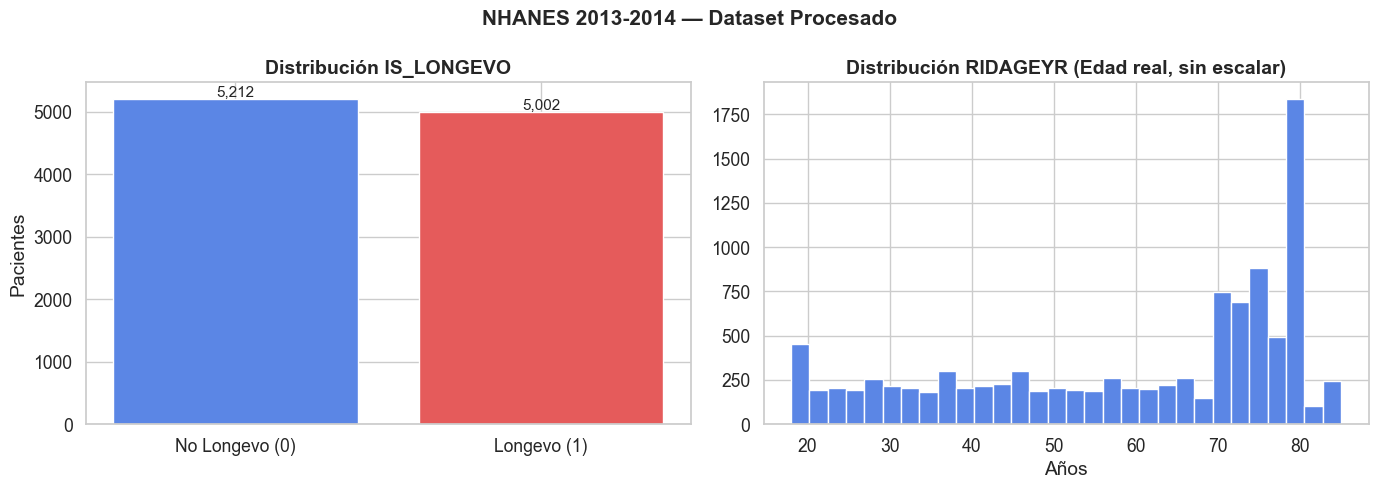

In [12]:
# Distribución de IS_LONGEVO
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

conteo = df_encoded['IS_LONGEVO'].value_counts()
axes[0].bar(['No Longevo (0)', 'Longevo (1)'], conteo.values,
            color=['#5B86E5', '#E55B5B'])
axes[0].set_title('Distribución IS_LONGEVO')
axes[0].set_ylabel('Pacientes')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontsize=11)

# Histograma de RIDAGEYR (sin escalar — se mantiene en años)
axes[1].hist(df_encoded['RIDAGEYR'], bins=30, color='#5B86E5', edgecolor='white')
axes[1].set_title('Distribución RIDAGEYR (Edad real, sin escalar)')
axes[1].set_xlabel('Años')

plt.suptitle(f'NHANES 2013-2014 — Dataset Procesado', fontsize=15, fontweight='bold')
plt.tight_layout()

os.makedirs('../data/08_reporting', exist_ok=True)
plt.savefig('../data/08_reporting/02_distribucion_target.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Resumen del dataset final

In [13]:
todas_las_features = [c for c in df_encoded.columns
                       if c not in ('SEQN', 'RIDAGEYR', 'IS_LONGEVO', 'CICLO_ORIGEN')]

print("=" * 60)
print("RESUMEN DEL DATASET PROCESADO")
print("=" * 60)
print(f"  Filas             : {df_encoded.shape[0]:,}")
print(f"  Columnas totales  : {df_encoded.shape[1]}")
print(f"  Features          : {len(todas_las_features)}")
print(f"    - Numéricas escaladas: {len(cols_a_escalar)}")
print(f"    - Variables dummy    : {len(cols_dummy)}")
print(f"  Nulos restantes   : {df_encoded.isnull().sum().sum()}")
print(f"  Target binario IS_LONGEVO (0/1)")
print(f"  Target continuo RIDAGEYR (sin escalar)")
print("=" * 60)
df_encoded.describe().T.round(3)

RESUMEN DEL DATASET PROCESADO
  Filas             : 10,214
  Columnas totales  : 42
  Features          : 38
    - Numéricas escaladas: 19
    - Variables dummy    : 19
  Nulos restantes   : 0
  Target binario IS_LONGEVO (0/1)
  Target continuo RIDAGEYR (sin escalar)


,count,mean,std,min,25%,50%,75%,max
SEQN,10214.0,69950.665,16282.542,31130.000,56582.750,76902.500,81064.500,93697.000
RIDAGEYR,10214.0,59.162,20.435,18.000,42.000,68.000,77.000,85.000
DMDHHSIZ,10214.0,0.000,1.000,-1.112,-0.508,-0.508,0.699,2.511
DMDFMSIZ,10214.0,-0.000,1.000,-1.037,-1.037,-0.432,0.779,2.595
INDFMPIR,10214.0,0.000,1.000,-1.592,-0.843,-0.219,0.761,1.695
BMXWT,10214.0,0.000,1.000,-2.314,-0.677,-0.132,0.513,7.125
BMXHT,10214.0,0.000,1.000,-3.601,-0.708,-0.050,0.708,3.671
BMXBMI,10214.0,0.000,1.000,-2.385,-0.667,-0.142,0.460,8.382
BMXWAIST,10214.0,0.000,1.000,-2.843,-0.678,-0.064,0.576,5.068
BMXLEG,10214.0,0.000,1.000,-4.287,-0.657,-0.009,0.666,3.596


## 13. Exportación a `data/02_intermediate`

In [14]:
OUTPUT_DIR  = '../data/02_intermediate'
OUTPUT_PATH = f'{OUTPUT_DIR}/nhanes_2013_procesado.parquet'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df_encoded.to_parquet(OUTPUT_PATH, index=False)
size_mb = os.path.getsize(OUTPUT_PATH) / 1024**2
print(f"✓ Dataset guardado en: {OUTPUT_PATH}")
print(f"  Tamaño: {size_mb:.2f} MB | {df_encoded.shape[0]:,} filas × {df_encoded.shape[1]} cols")

# Verificación
df_verify = pd.read_parquet(OUTPUT_PATH)
assert df_verify.shape == df_encoded.shape, "ERROR: dimensiones distintas al releer."
assert df_verify.isnull().sum().sum() == 0, "ERROR: se introdujeron nulos al guardar."
print("✓ Verificación exitosa — el archivo se lee correctamente.")

✓ Dataset guardado en: ../data/02_intermediate/nhanes_2013_procesado.parquet
  Tamaño: 0.39 MB | 10,214 filas × 42 cols
✓ Verificación exitosa — el archivo se lee correctamente.


## 14. Exportación de metadatos JSON

In [15]:
metadata = {
    "archivo_origen"        : "nhanes_2013_maestra.csv",
    "archivo_procesado"     : "nhanes_2013_procesado.parquet",
    "n_filas"               : int(df_encoded.shape[0]),
    "n_columnas"            : int(df_encoded.shape[1]),
    "col_id"                : col_id,
    "col_target_binario"    : col_target_bin,
    "col_target_continuo"   : col_target_cont,
    "cols_numericas_escaladas": cols_a_escalar,
    "cols_dummy"            : cols_dummy,
    "todas_las_features"    : todas_las_features,
    "umbral_longevidad"     : 70,
    "filtro_edad_minima"    : 18,
    "sas_missing_corregidos": n_sas_total,
}

meta_path = f'{OUTPUT_DIR}/metadata_preprocesamiento_2013.json'
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"✓ Metadatos guardados en: {meta_path}")
print(json.dumps(metadata, indent=2, ensure_ascii=False)[:600], "...")

✓ Metadatos guardados en: ../data/02_intermediate/metadata_preprocesamiento_2013.json
{
  "archivo_origen": "nhanes_2013_maestra.csv",
  "archivo_procesado": "nhanes_2013_procesado.parquet",
  "n_filas": 10214,
  "n_columnas": 42,
  "col_id": "SEQN",
  "col_target_binario": "IS_LONGEVO",
  "col_target_continuo": "RIDAGEYR",
  "cols_numericas_escaladas": [
    "DMDHHSIZ",
    "DMDFMSIZ",
    "INDFMPIR",
    "BMXWT",
    "BMXHT",
    "BMXBMI",
    "BMXWAIST",
    "BMXLEG",
    "BMXARML",
    "BMXARMC",
    "BPXSY1",
    "BPXDI1",
    "BPXSY2",
    "BPXDI2",
    "BPXSY3",
    "BPXDI3",
    "BPXPLS",
    "LBXTC",
    "LBXGLU"
  ],
  "cols_dummy": [
    "RIAGENDR_2",
    "RIDRETH3_2 ...


## 15. Conclusiones del Preprocesamiento

1. **Corrección SAS missing** — valores centinela `5.4e-79` convertidos a `NaN` real.
2. **Selección de variables** — de ~288 a ~25 columnas relevantes (demográficas, antropometría, presión, laboratorio).
3. **Filtrado** — solo adultos ≥18 años, sin registros sin edad.
4. **Imputación** — `KNNImputer` k=5 para numéricas; `SimpleImputer` moda para categóricas → 0 nulos.
5. **Codificación** — One-Hot Encoding con `drop_first=True`.
6. **Escalado** — `StandardScaler` aplicado a las 19 variables numéricas (no escala targets ni dummies).
7. **Variable objetivo** — `IS_LONGEVO` = 1 si `RIDAGEYR ≥ 70`.
8. **Exportación** — `nhanes_2013_procesado.parquet` + `metadata_preprocesamiento_2013.json`.

**Siguiente paso → Notebook 03: Aprendizaje No Supervisado (PCA + K-Means)**

---
*Notebook generado como parte del pipeline EV3 NHANES 2013-2014*